In [81]:
import mne
from scipy.stats import ttest_1samp
from matplotlib import pyplot as plt

In [ ]:
data_path = mne.datasets.sample.data_path()
meg_path = data_path / "MEG" / "sample"
raw_fname = meg_path / "sample_audvis_raw.fif"
event_fname = meg_path / "sample_audvis_raw-eve.fif"
raw = mne.io.read_raw_fif(raw_fname, preload=True, verbose=False)
raw.filter(1, 25, verbose=False)
epochs = mne.Epochs(
    raw,
    events= mne.read_events(event_fname),
    event_id = {"AudL": 1, "AudR": 2, "VisL": 3, "VisR": 4},
    tmin=-0.2,
    tmax=0.5,
    picks = mne.pick_types(raw.info, meg="mag", eog=True),
    decim=2,
    baseline=None,
    reject=dict(mag=4e-12, eog=150e-6),
    preload=True,
    verbose=False,
)
epochs.equalize_event_counts()
epochs.pick("mag")

# Comparing Evoked Responses

In [ ]:
evoked = epochs["AudL"].average()
evoked.plot();

Plot the response over left auditory cortex.

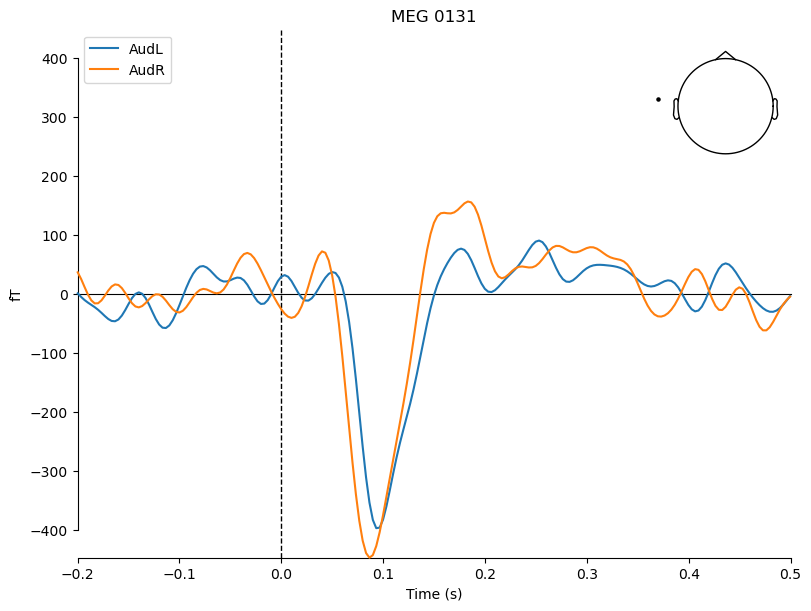

In [83]:
evokeds = [epochs["AudL"].average(), epochs["AudR"].average()]
mne.viz.plot_compare_evokeds(evokeds, picks=["MEG 0131"]);

Plot response over right auditory cortex.

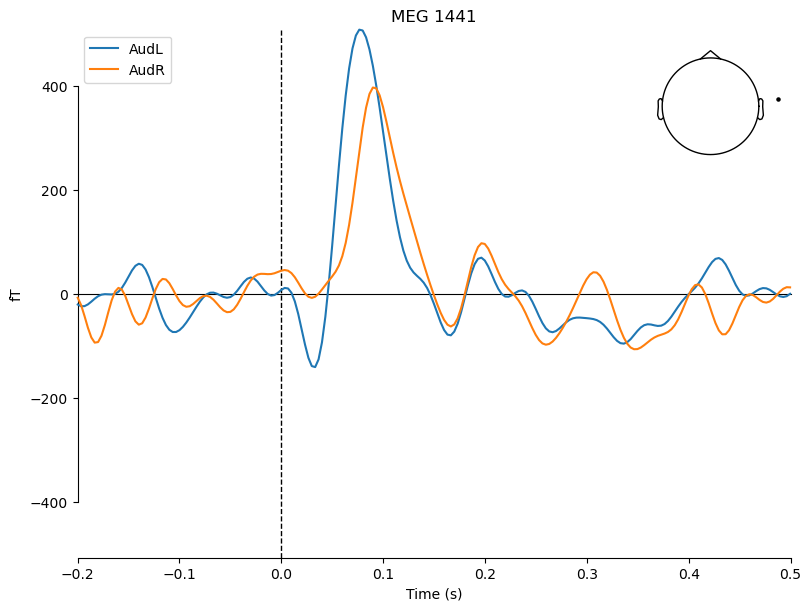

[<Figure size 800x600 with 2 Axes>]

In [84]:
evokeds = [epochs["AudL"].average(), epochs["AudR"].average()]
mne.viz.plot_compare_evokeds(evokeds, picks=["MEG 1441"])

Plot response over left occipital cortex.

In [ ]:
evokeds = [epochs["VisL"].average(), epochs["VisR"].average()]
mne.viz.plot_compare_evokeds(evokeds, picks=["MEG 1731"]);

Get evoked response per condition.

In [ ]:
evokeds = epochs.average(by_event_type=True)
evokeds = {e.comment: e for e in evokeds}

Compare response to left and right auditory stimulus.

In [ ]:
diff = mne.combine_evoked([evokeds["AudL"], evokeds["AudR"]], weights=[1, -1])
diff.plot_joint();

Compare response to left and right visual stimulus.

In [ ]:
diff = mne.combine_evoked([evokeds["VisL"], evokeds["VisR"]], weights=[1, -1])
diff.plot_joint();

# Statistical Comparison of ERPs

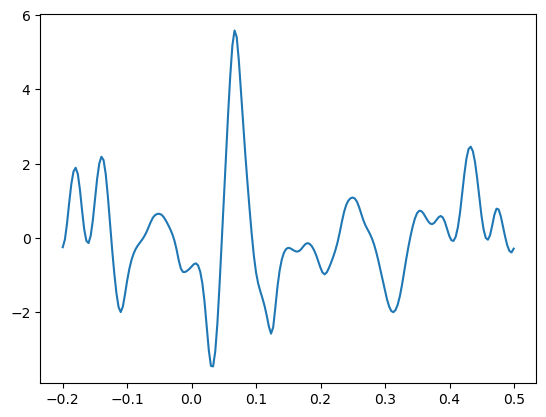

In [101]:
data_audL = epochs["AudL"].get_data(picks=["MEG 1441"])
data_audR = epochs["AudR"].get_data(picks=["MEG 1441"])
diff = data_audL - data_audR
t, p = ttest_1samp(diff, popmean=0)
plt.plot(epochs.times, t.flatten())

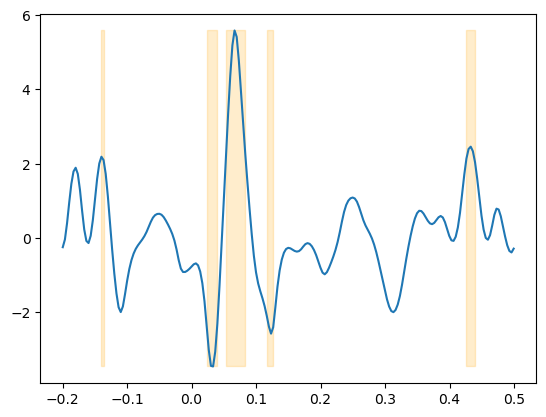

In [ ]:
p_thresh= 0.05
plt.plot(epochs.times, t_values.flatten())
plt.fill_between(epochs.times, t_values.flatten().min(), t_values.flatten().max(),
                 where=p.flatten()<p_thresh, alpha=0.2, color="orange")

# Correcting for Multiple Comparisons

In [103]:
data_audL = epochs["AudL"].get_data(picks=["MEG 1441"])
data_audR = epochs["AudR"].get_data(picks=["MEG 1441"])
diff = data_audL - data_audR
t, p = ttest_1samp(diff, popmean=0)

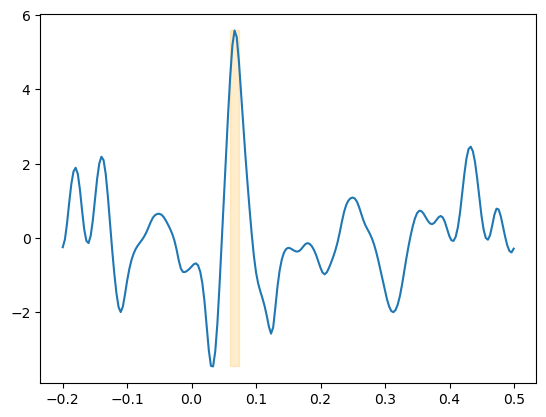

In [105]:
_, p_bonferroni = mne.stats.bonferroni_correction(p)
p_thresh= 0.05
plt.plot(epochs.times, t_values.flatten())
plt.fill_between(epochs.times, t_values.flatten().min(), t_values.flatten().max(),
                 where=p_bonferroni.flatten()<p_thresh, alpha=0.2, color="orange")

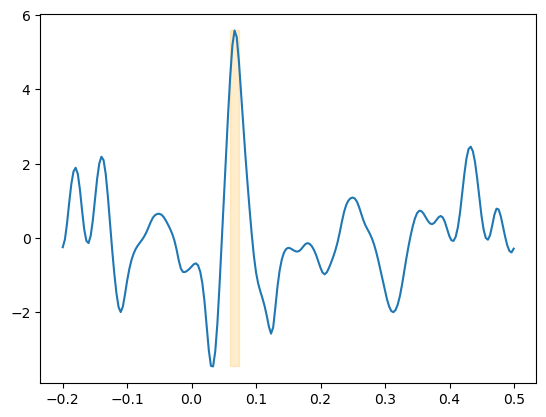

In [106]:
_, p_fdr = mne.stats.fdr_correction(p)
p_thresh= 0.05
plt.plot(epochs.times, t_values.flatten())
plt.fill_between(epochs.times, t_values.flatten().min(), t_values.flatten().max(),
                 where=p_bonferroni.flatten()<p_thresh, alpha=0.2, color="orange")

# Permutation Cluster Test